In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


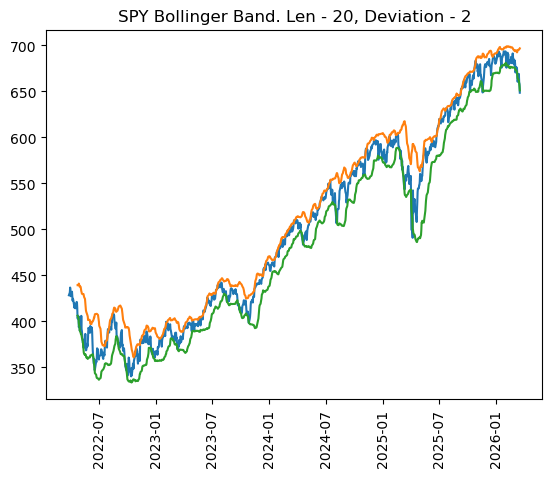

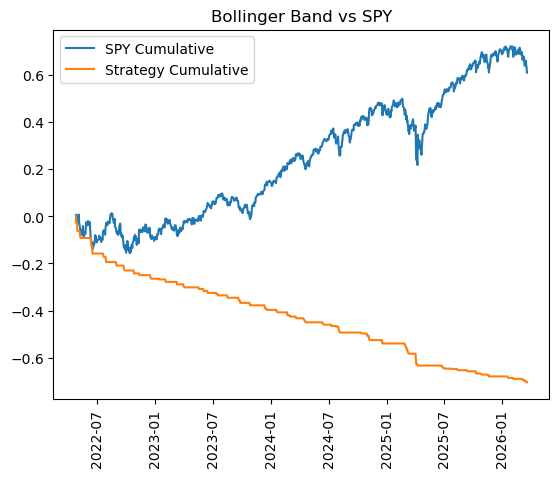

In [34]:
TICKER = 'SPY'
BB_LEN = 20
DEVS = 2
LOOKBACK = 1000

def get_data(ticker=TICKER,lookback=LOOKBACK):
    df = yf.download(ticker,start='2000-01-01')
    df.columns = df.columns.get_level_values(0)

    return df.iloc[-lookback:, :]

def add_bollinger_bands(df,devs=DEVS, bb_len=BB_LEN):

    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band']  = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band']  = df['BB_SMA'] - (devs * df['BB_STD'])

    plt.plot(df['Close'])
    plt.plot(df['Upper_Band'])
    plt.plot(df['Lower_Band'])
    plt.xticks(rotation='vertical')

    df = df.dropna()

    plt.title(f'{TICKER} Bollinger Band. Len - {BB_LEN}, Deviation - {DEVS}')


    return df

def add_strategy(df):
    df['Strategy'] = 0
    df['Strategy'] = np.where(df['Close'] > df['Upper_Band'], -1,
                              np.where(df['Close'] < df['Lower_Band'],1,0))
    
    return df


def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod()  -1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod()  -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.title(f'Bollinger Band vs {TICKER}')
    plt.xticks(rotation='vertical')

def main():
    df  = get_data()
    df = add_bollinger_bands(df)
    df = add_strategy(df)
    df = test_strategy(df)

    return df


df = main()

In [36]:
df